In [3]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path

from eval_fluent_deeponet import (
    InterfaceIterationConfig,
    iterative_unknown_interface_inference,
    simulated_annealing_unknown_interface_inference,
    make_plot_dict_from_iterative_result,
    select_sample_indices_by_ar,
    infer_edge_layout,
)

from fluent_deeponet import DeepONet, FeatureNormalizer
from deeponet_fluent_dataset import build_fluent_deeponet_dataset

from plot import plot_prediction_imshow_from_points

In [2]:
device = torch.device("cuda:3")
ckpt_path = Path("results") / "052426_1" / "checkpoint.pt"
ckpt = torch.load(ckpt_path, map_location=device)

best_model = DeepONet(**ckpt["model_config"]).to(device)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()


/tmp/ipykernel_3549594/3091633078.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


DeepONet(
  (branch_net): PointSetBranchNet(
    (point_encoder): Sequential(
      (0): Linear(in_features=13, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): GELU(approximate='none')
      (4): Linear(in_features=128, out_features=128, bias=True)
    )
    (global_mlp): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): GELU(approximate='none')
      (4): Linear(in_features=128, out_features=512, bias=True)
    )
  )
  (trunk_net): TrunkNet(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): GELU(approximate='none')
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): GELU(approximate='none')
   

In [107]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/runs_2d/rect_ar")

available_ars = list(range(1, 51))

case_files = {
    i: {
        "mesh": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/rect_ar{i:02d}.msh.h5",
        "dat": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/case2d.dat.h5",
    }
    for i in available_ars
}

# Quick path check for the ARs used below.
for ar in [10, 20, 30, 50]:
    print(ar, case_files[ar]["mesh"].exists(), case_files[ar]["dat"].exists())

bc_kwargs = {
    "inlet_u": 0.1,
    "inlet_v": 0.0,
    "inlet_T": 273.0,
    "outlet_p": 0.0,
    "top_T": 273.0,
    "bottom_T": 275.0,
    "wall_u": 0.0,
    "wall_v": 0.0,
}

TEST_AR = 50

test_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    ar_list=[TEST_AR],
    n_subdomains=20,
    n_interface_points=256,
    n_boundary_points=256,
    interface_placement="fixed",
    interface_jitter=0,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
)

10 True True
20 True True
30 True True
50 True True
Processing AR=50 realization=0


In [414]:
y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(device)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])
sample_test_ids = select_sample_indices_by_ar(test_data, ar=TEST_AR)

config = InterfaceIterationConfig(
    max_iter=10,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1,
    random_seed=0,
    init_mode="fixed_value",
    init_std_scale=1.0,
    init_value=[0, 273, 0, 0],
    init_noise_std=0,
    query_batch_size=32768,
    sample_batch_size=20,
    preserve_wall_corners=False,
    verbose=True,
)

test_result = iterative_unknown_interface_inference(
    model=best_model,
    samples_for_ar=[test_data["samples"][i] for i in sample_test_ids],
    branch_channel_names=test_data["branch_channel_names"],
    device=device,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    config=config,
)

print("Converged:", test_result["converged"], "iterations:", test_result["n_iter"])
print("Final prediction samples:", len(test_result["pred_samples"]))


iter=0001 | interface MSE max=3.621617e-01, mean=1.271188e-01 | converged=0/19


iter=0002 | interface MSE max=9.720060e-02, mean=8.852364e-02 | converged=0/19
iter=0003 | interface MSE max=1.204379e-01, mean=1.032613e-01 | converged=0/19
iter=0004 | interface MSE max=1.271425e-01, mean=1.050989e-01 | converged=0/19
iter=0005 | interface MSE max=1.332442e-01, mean=1.071616e-01 | converged=0/19
iter=0006 | interface MSE max=1.399189e-01, mean=1.099188e-01 | converged=0/19
iter=0007 | interface MSE max=1.471938e-01, mean=1.132069e-01 | converged=0/19
iter=0008 | interface MSE max=1.551195e-01, mean=1.169514e-01 | converged=0/19
iter=0009 | interface MSE max=1.637534e-01, mean=1.211213e-01 | converged=0/19
iter=0010 | interface MSE max=1.731889e-01, mean=1.257077e-01 | converged=0/19
Converged: False iterations: 10
Final prediction samples: 20


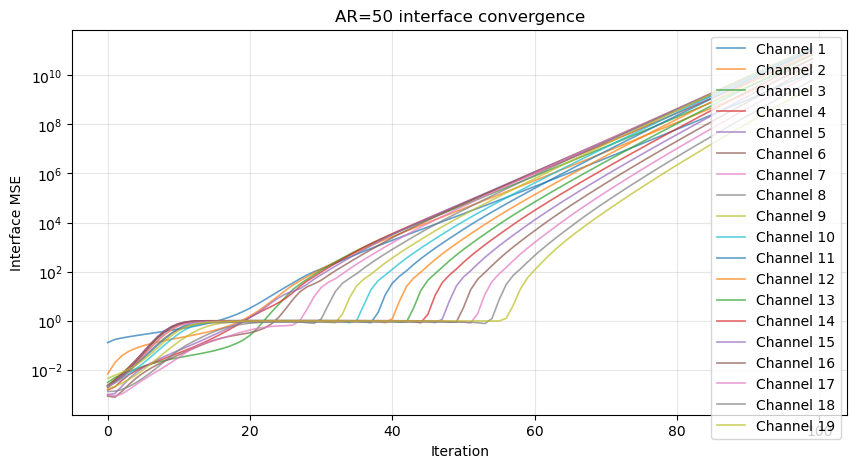

In [311]:
mse_history = test_result["interface_mse_history"]
plt.figure(figsize=(10, 5))
for k in range(mse_history.shape[1]):
    plt.plot(mse_history[:, k], alpha=0.7, linewidth=1.2, label=f"Channel {k+1}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Interface MSE")
plt.title(f"AR={TEST_AR} interface convergence")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

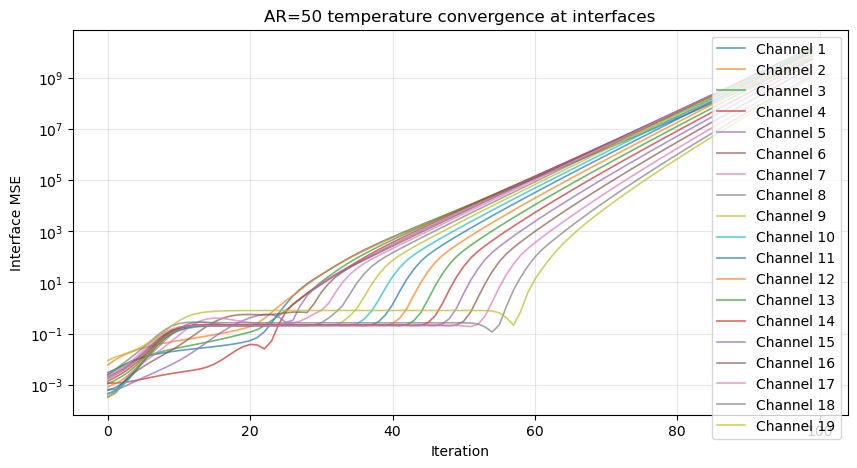

In [312]:
channel_history = test_result["interface_mse_by_channel_history"]
plt.figure(figsize=(10, 5))
for k in range(channel_history.shape[1]):
    plt.plot(channel_history[:, k, 1], alpha=0.7, linewidth=1.2, label=f"Channel {k+1}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Interface MSE")
plt.title(f"AR={TEST_AR} temperature convergence at interfaces")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

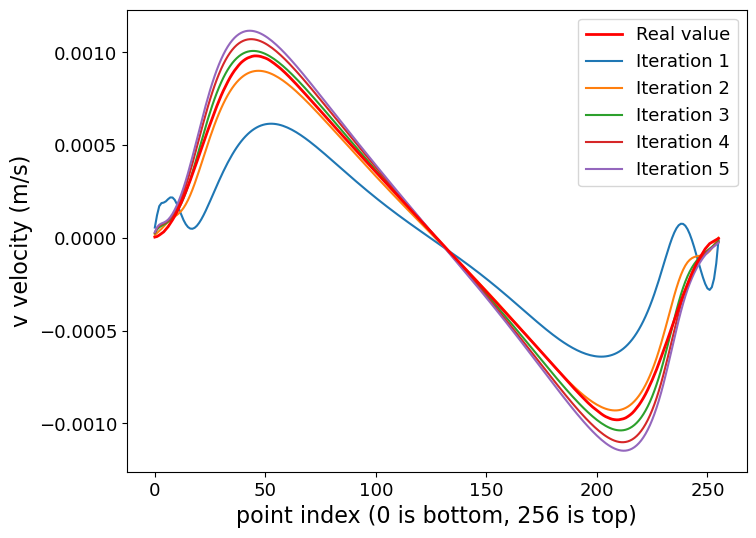

In [425]:
int_id = 1
val_id = 3
range_i = (0, 5)
br = test_data["samples"][sample_test_ids[int_id]]["branch"]
real_t = br[(br[:, 0] == 0) & (br[:, 3] == 1)][:, val_id + 4]
t_history = test_result["interface_left_values_history"][:, int_id, :, val_id]

plt.figure(figsize=(8, 6))
plt.plot(real_t, zorder=10, lw=2, label="Real value", c="r")
for i in range(range_i[0], range_i[1]):
    plt.plot(t_history[i, :], label=f"Iteration {i+1}")
    
plt.xlabel("point index (0 is bottom, 256 is top)", fontsize=16)
plt.ylabel("v velocity (m/s)", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
leg = plt.legend(loc=1, fontsize=13)
leg.set_zorder(20)
plt.show()


In [477]:
# Simulated annealing interface solve: minimize predicted interface mismatch only.
# This does not add smoothness/range/truth penalties.

sa_config = InterfaceIterationConfig(
    max_iter=0,              # not used by SA, but kept for result compatibility
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1.0,          # not used by SA
    random_seed=0,
    init_mode="pointwise_random",   # change to "pointwise_random" for unknown-interface testing
    init_std_scale=1.0,
    init_value=[0, 273, 0, 0],
    init_noise_std=0.0,
    query_batch_size=32768,
    sample_batch_size=20,
    preserve_wall_corners=False,
    verbose=True,
)

test_result_sa = simulated_annealing_unknown_interface_inference(
    model=best_model,
    samples_for_ar=[test_data["samples"][i] for i in sample_test_ids],
    branch_channel_names=test_data["branch_channel_names"],
    device=device,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    config=sa_config,
    n_steps=20000,
    temperature0=None,          # None -> 0.1 * initial energy
    temperature_min=1.0e-8,
    proposal_sigma0=0.05,       # normalized output units
    proposal_sigma_min=0.001,
    proposal_location="channel",
    sample_mode="fixed",
    objective="max",
    verbose_every=100,
)

print("SA converged:", test_result_sa["converged"], "steps:", test_result_sa["n_iter"])
print("Best energy:", test_result_sa["best_energy"])
print("Best max MSE:", np.max(test_result_sa["best_interface_mse_history"][-1]))

Initial energy: 1.021135e-01
Initializing temperature
Initial temperature: 3.372766e-02
sa_step=00100 | E=1.146393e-01 | best_E=9.025576e-02 | max_mse=1.146393e-01 | mean_mse=7.841682e-02 | best_max_mse=9.025576e-02 | T=3.129e-02 | sigma=4.903e-02 | accepted=True
sa_step=00200 | E=1.262074e-01 | best_E=9.025576e-02 | max_mse=1.262074e-01 | mean_mse=7.705055e-02 | best_max_mse=9.025576e-02 | T=2.902e-02 | sigma=4.808e-02 | accepted=True
sa_step=00300 | E=1.223940e-01 | best_E=9.025576e-02 | max_mse=1.223940e-01 | mean_mse=7.757661e-02 | best_max_mse=9.025576e-02 | T=2.692e-02 | sigma=4.715e-02 | accepted=True
sa_step=00400 | E=1.401627e-01 | best_E=9.025576e-02 | max_mse=1.401627e-01 | mean_mse=8.265778e-02 | best_max_mse=9.025576e-02 | T=2.497e-02 | sigma=4.624e-02 | accepted=True
sa_step=00500 | E=1.696612e-01 | best_E=9.025576e-02 | max_mse=1.696612e-01 | mean_mse=8.358108e-02 | best_max_mse=9.025576e-02 | T=2.316e-02 | sigma=4.534e-02 | accepted=True
sa_step=00600 | E=1.639550e-01 |

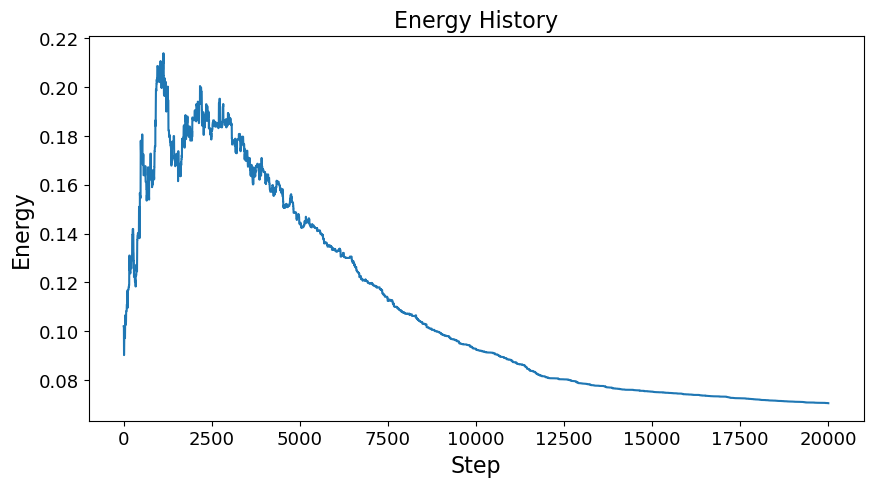

In [478]:
plt.figure(figsize=(10, 5))
plt.plot(test_result_sa["energy_history"])
plt.xlabel("Step", fontsize=16)
plt.ylabel("Energy", fontsize=16)
plt.title("Energy History", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()


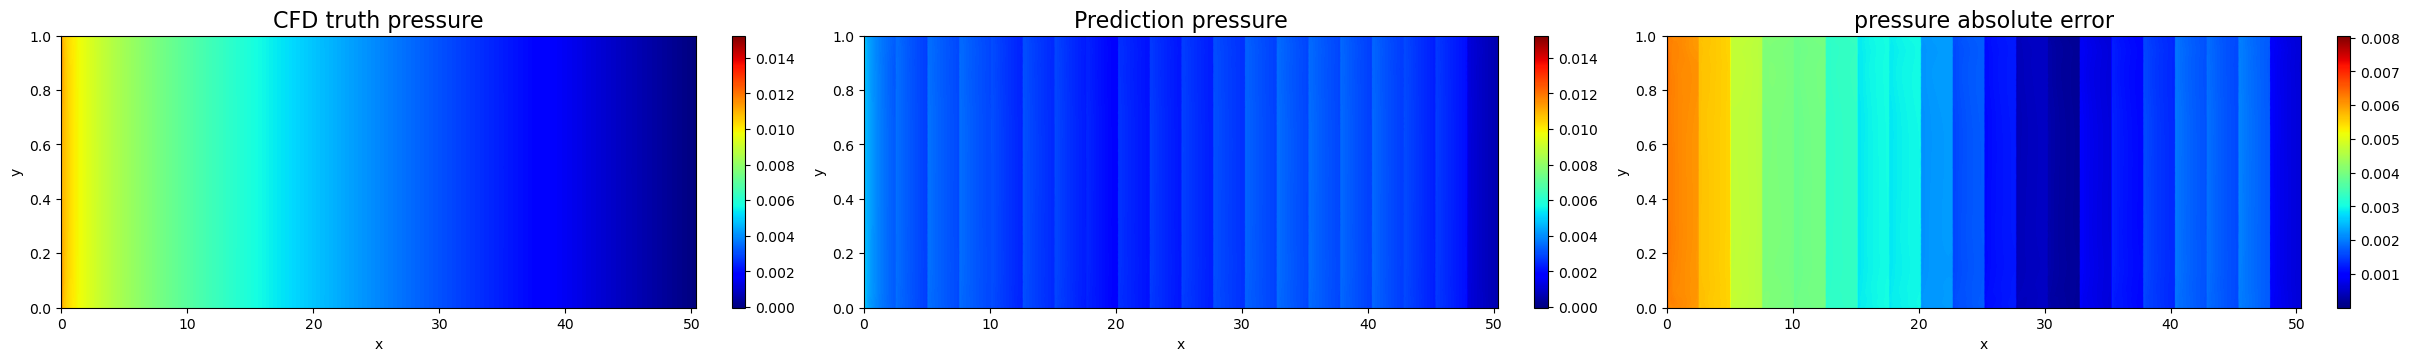

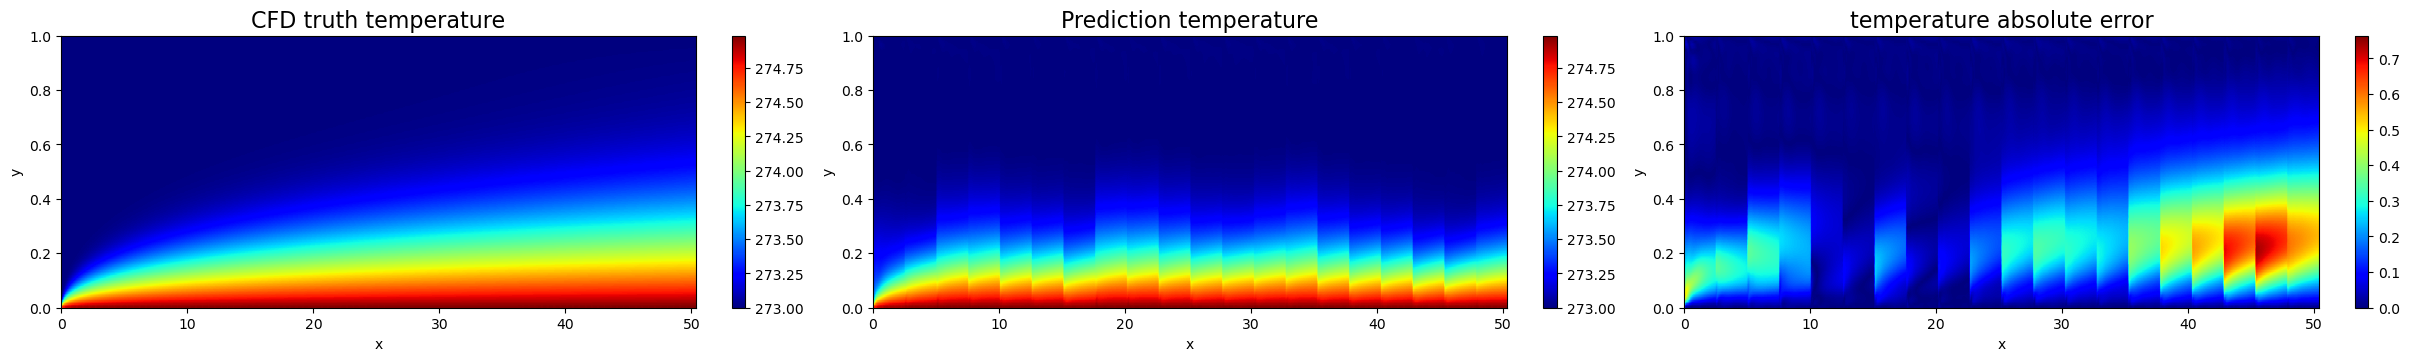

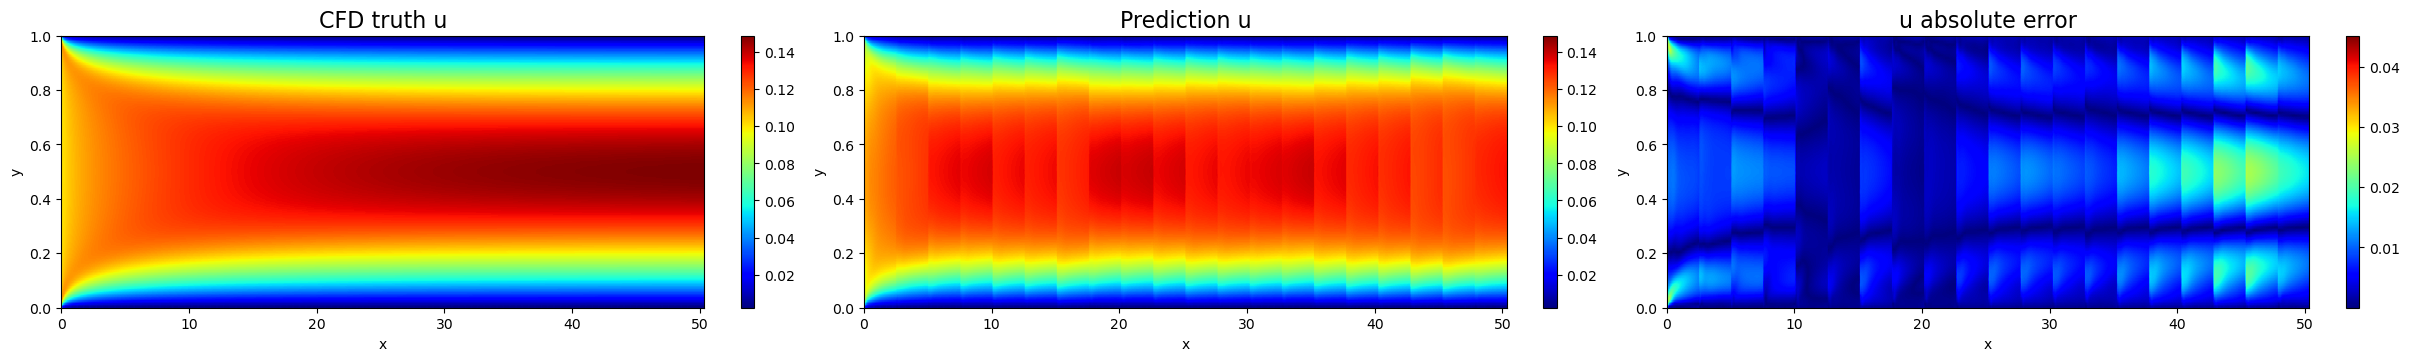

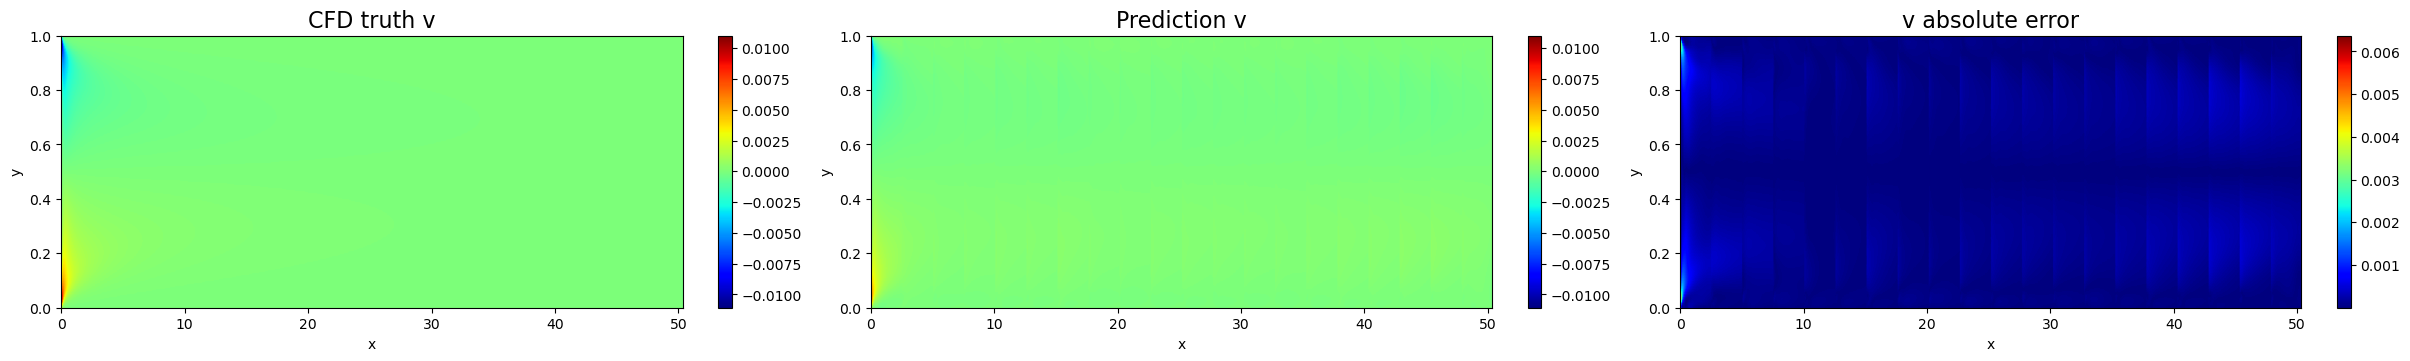

In [479]:
p_plot = make_plot_dict_from_iterative_result(
    result=test_result_sa,
    data=test_data,
    sample_indices=sample_test_ids,
    nondimensionalize_xy=True,
)

output_channel_names = test_data["output_channel_names"]
for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=p_plot["x"],
        y=p_plot["y"],
        pred=p_plot["pred"],
        truth=p_plot["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_y_plot=100,
    )

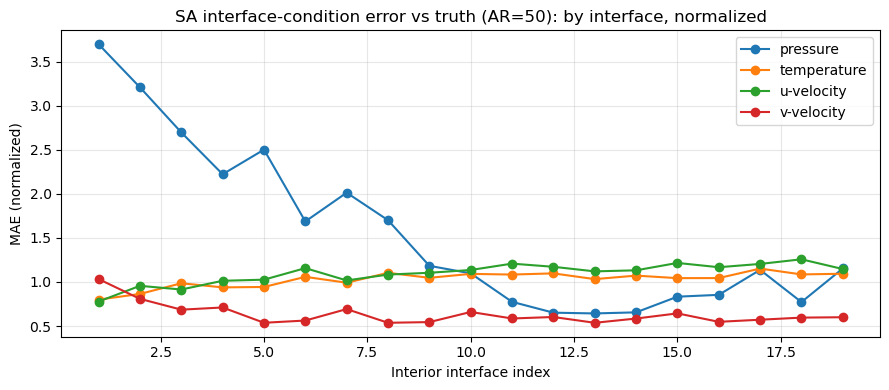

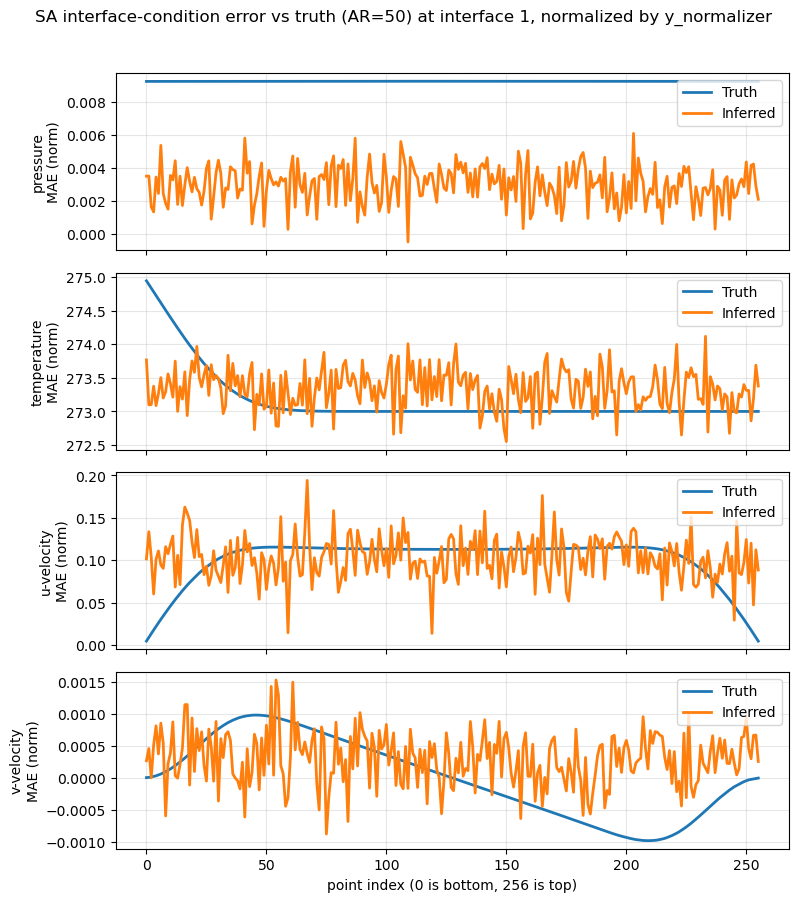

Global MAE per channel normalized:
                pressure: 1.551388e+00
             temperature: 1.027875e+00
              u-velocity: 1.095354e+00
              v-velocity: 6.339576e-01
Overall MAE (all interfaces, points, channels): 1.0771441459655762


In [480]:
true_branch = np.stack([test_data["samples"][i]["branch"] for i in sample_test_ids], axis=0).astype(np.float32)
infer_branch = np.asarray(test_result_sa["branch_final"], dtype=np.float32)

layout = infer_edge_layout(true_branch[0], test_data["branch_channel_names"])
channel_labels = ["pressure", "temperature", "u-velocity", "v-velocity"]

n_sub = true_branch.shape[0]

true_interfaces = []
infer_interfaces = []
for interface_id in range(1, n_sub):
    i_right = infer_branch[interface_id - 1][np.ix_(layout.right, value_idx)]
    i_left = infer_branch[interface_id][np.ix_(layout.left, value_idx)]

    true_interfaces.append(true_branch[interface_id][np.ix_(layout.left, value_idx)])
    infer_interfaces.append(0.5 * (i_right + i_left))

true_interfaces = np.stack(true_interfaces, axis=0)   # (n_if, n_y, n_ch)
infer_interfaces = np.stack(infer_interfaces, axis=0) # (n_if, n_y, n_ch)

err = infer_interfaces - true_interfaces

yn_mean = y_normalizer.mean.detach().cpu().numpy().astype(np.float32).reshape(1, 1, -1)
yn_std = y_normalizer.std.detach().cpu().numpy().astype(np.float32).reshape(1, 1, -1)
yn_std = np.maximum(yn_std, 1.0e-12)

true_interfaces_norm = (true_interfaces - yn_mean) / yn_std
infer_interfaces_norm = (infer_interfaces - yn_mean) / yn_std
err_norm = infer_interfaces_norm - true_interfaces_norm
abs_err_norm = np.abs(err_norm)

# Figure 1: MAE by interface (line per channel)
mae_if_ch = abs_err_norm.mean(axis=1)  # (n_if, n_ch)
plt.figure(figsize=(9, 4))
for ch in range(mae_if_ch.shape[1]):
    plt.plot(np.arange(1, mae_if_ch.shape[0] + 1), mae_if_ch[:, ch], marker='o', label=channel_labels[ch])
plt.xlabel("Interior interface index")
plt.ylabel("MAE (normalized)")
plt.title(f"SA interface-condition error vs truth (AR={TEST_AR}): by interface, normalized")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Error along y at given interface
int_eval = 1
fig, axes = plt.subplots(4, 1, figsize=(8, 2.2 * 4), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(true_interfaces[int_eval-1, :, ch], lw=2, label="Truth")
    ax.plot(infer_interfaces[int_eval-1, :, ch], lw=2, label="Inferred")
    ax.set_ylabel(f"{channel_labels[ch]}\nMAE (norm)")
    ax.legend(loc=1)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("point index (0 is bottom, 256 is top)")
fig.suptitle(f"SA interface-condition error vs truth (AR={TEST_AR}) at interface {int_eval}, normalized by y_normalizer", y=1.02)
fig.tight_layout()
plt.show()

global_mae_ch = abs_err_norm.mean(axis=(0, 1))
print("Global MAE per channel normalized:")
for label, val in zip(channel_labels, global_mae_ch):
    print(f"  {label:>22s}: {val:.6e}")
print("Overall MAE (all interfaces, points, channels):", float(abs_err_norm.mean()))